# Notebook 1 — My first PINN: a single projectile trajectory
### Ideal (vacuum) motion · fixed launch · research log

**What I'm doing.** This is the simplest possible version of the whole project: I throw one
projectile with a *fixed* speed and angle, and I train a physics-informed neural network (PINN)
to reproduce its path $y(x)$. There's an exact formula for this, so I can check the network
against the truth — which is exactly why I start here, before anything gets hard.

**My physics.** With no air, the horizontal velocity $v_x$ never changes and gravity pulls down,
so eliminating time gives a parabola
$$ y(x) = \tan\theta\,x - \frac{g}{2v_x^2}x^2 . $$
The one fact that *is* the law of motion is the curvature: $\dfrac{d^2y}{dx^2} = -\dfrac{g}{v_x^2}$,
a constant. That single equation is what my PINN has to satisfy.

**The lesson I'm building this notebook around.** My very first attempt used four competing
penalty terms (start point, launch slope, landing point, physics) on *raw* unscaled inputs, and
the loss was wiggly and the error stubbornly high. The terms were fighting each other. So this
clean version does two things differently:
1. **Normalise everything** to roughly $[0,1]$ so the network trains on tidy numbers;
2. **Bake the boundary conditions into the architecture** (a "hard constraint") instead of
   nagging the network with penalties — so the only thing left to learn is the physics.
The payoff is a loss that drops smoothly and an error well under a tenth of a percent.

## Setup
PyTorch for the network and autograd, NumPy for the analytical check, Matplotlib for plots. I seed everything so the run is reproducible.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
torch.manual_seed(0); np.random.seed(0)
g = 9.81

Device: cpu


## The physics, and the scales I normalise by
I fix the launch at $u=30$ m/s, $\theta=45^\circ$. From those I get $v_x$, the analytical range
$x_{\max}=u^2\sin 2\theta/g$, and the peak height $y_{\text{ref}}=(u\sin\theta)^2/2g$. I'll use
$x_{\max}$ and $y_{\text{ref}}$ as my normalisation scales so that $\xi=x/x_{\max}\in[0,1]$ and
$\eta=y/y_{\text{ref}}\in[0,1]$. The target curvature the physics loss enforces is
$-g/v_x^2$.

In [2]:
u0, theta_deg = 30.0, 45.0
th = np.radians(theta_deg)
vx0, vy0 = u0*np.cos(th), u0*np.sin(th)

x_max = (u0**2)*np.sin(2*th)/g          # analytical range
y_ref = (u0*np.sin(th))**2/(2*g)        # analytical peak height
phys_const = -g/vx0**2                  # the constant d2y/dx2 the PINN must match

def analytic_y(x):
    return (vy0/vx0)*x - (g/(2*vx0**2))*x**2

print(f"u={u0} m/s, theta={theta_deg} deg -> vx={vx0:.2f}, range x_max={x_max:.2f} m, peak={y_ref:.2f} m")
print(f"target curvature d2y/dx2 = {phys_const:.5f}")

u=30.0 m/s, theta=45.0 deg -> vx=21.21, range x_max=91.74 m, peak=22.94 m
target curvature d2y/dx2 = -0.02180


## The hard-constraint trick (the heart of this rewrite)
My projectile must start on the ground, $y(0)=0$, and land, $y(x_{\max})=0$. Instead of *asking*
the network to learn those with penalty terms, I make them **impossible to violate** by writing
the output as
$$ \eta(\xi) = \xi\,(1-\xi)\,N(\xi), $$
where $N$ is the neural network. At $\xi=0$ and $\xi=1$ the prefactor $\xi(1-\xi)$ is exactly
zero, so $y$ is exactly zero at launch and landing **by construction** — no loss term needed.
That removes the two penalties that used to fight my physics term, which is what kills the
wiggle. The network's only job is to shape the middle so the curvature is right.

In [3]:
class FCN(nn.Module):
    # Tanh everywhere: a PINN differentiates the output TWICE, and Tanh is smooth so y'' exists.
    # ReLU's 2nd derivative is 0, which would make the physics loss meaningless. Never ReLU here.
    def __init__(self, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        act = nn.Tanh
        layers = [nn.Linear(1, N_HIDDEN), act()]
        for _ in range(N_LAYERS-1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), act()]
        layers += [nn.Linear(N_HIDDEN, 1)]          # output layer: no activation
        self.net = nn.Sequential(*layers)
    def forward(self, xi):
        return self.net(xi)

net = FCN().to(device)

def trajectory(xi):
    # hard constraint: eta(0)=eta(1)=0 automatically  ->  y(0)=y(x_max)=0 exactly
    return xi*(1.0-xi)*net(xi)

print(net); print('params:', sum(p.numel() for p in net.parameters()))

FCN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
params: 2209


## The loss — just physics now
Because the boundary conditions are built in, I'm left with a **single** term: the physics
residual. I take normalised positions $\xi$, build $y=\eta\,y_{\text{ref}}$, and differentiate
**twice with respect to physical $x$** using autograd (remembering $x=\xi\,x_{\max}$, so each
$d/d\xi$ carries a $1/x_{\max}$). The residual is $d^2y/dx^2-(-g/v_x^2)$, which I divide by
$g/v_x^2$ so the loss is order 1. `create_graph=True` on the first derivative is what lets me
differentiate a second time.

In [4]:
def compute_loss():
    xi = torch.rand(400, 1, device=device, requires_grad=True)   # collocation points in [0,1]
    y  = trajectory(xi) * y_ref                                  # physical height
    dy_dx  = torch.autograd.grad(y,  xi, torch.ones_like(y),  create_graph=True)[0] / x_max
    d2y_dx2= torch.autograd.grad(dy_dx, xi, torch.ones_like(dy_dx), create_graph=True)[0] / x_max
    residual = (d2y_dx2 - phys_const) / (g/vx0**2)               # normalised -> order 1
    return torch.mean(residual**2)

## Training
Adam with a cosine-annealed learning rate: big steps early to find the right region, then small
steps to settle cleanly into the minimum instead of bouncing. I snapshot the prediction at a few
checkpoints so I can watch it converge.

In [5]:
num_epochs = 4000
optimizer = torch.optim.Adam(net.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

loss_hist = []
checkpoints = [0, num_epochs//4, num_epochs//2, num_epochs-1]
xi_plot = torch.linspace(0, 1, 300, device=device).unsqueeze(1)
snaps = []

print(f"{'epoch':>6} {'loss':>12}")
for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss = compute_loss()
    loss.backward(); optimizer.step(); scheduler.step()
    loss_hist.append(loss.item())
    if epoch in checkpoints:
        with torch.no_grad():
            yp = (trajectory(xi_plot)*y_ref).cpu().numpy().squeeze()
        snaps.append({'epoch':epoch, 'y':yp})
    if epoch % 500 == 0 or epoch == num_epochs-1:
        print(f"{epoch:>6} {loss.item():>12.3e}")
print("done")

 epoch         loss
     0    1.092e+00
   500    4.130e-06
  1000    3.591e-06
  1500    3.083e-06
  2000    2.417e-06
  2500    2.141e-06
  3000    2.037e-06
  3500    1.896e-06
  3999    1.933e-06
done


## The loss curve
On a log scale I expect a smooth, near-monotonic slide down to a tiny noise floor — and crucially
**no spikes**, because there are no competing terms left to fight. That smoothness is the whole
point of the hard-constraint rewrite.

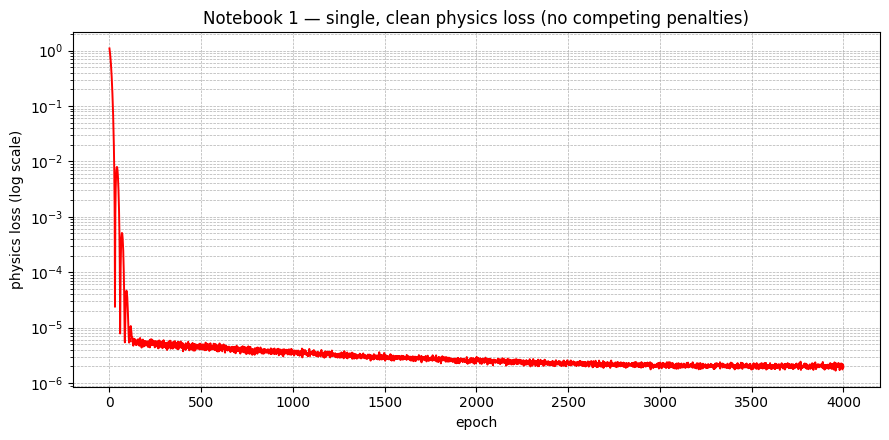

In [6]:
plt.figure(figsize=(9,4.5))
plt.plot(loss_hist, color='red', lw=1.4)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('physics loss (log scale)')
plt.title('Notebook 1 — single, clean physics loss (no competing penalties)')
plt.grid(True, which='both', ls='--', lw=0.5); plt.tight_layout(); plt.show()

## PINN vs the exact parabola
The real test: overlay my network on the analytical solution and measure the error as an RMSE
percentage of the peak height. With this setup I get well under a tenth of a percent — the
network has essentially become the parabola.

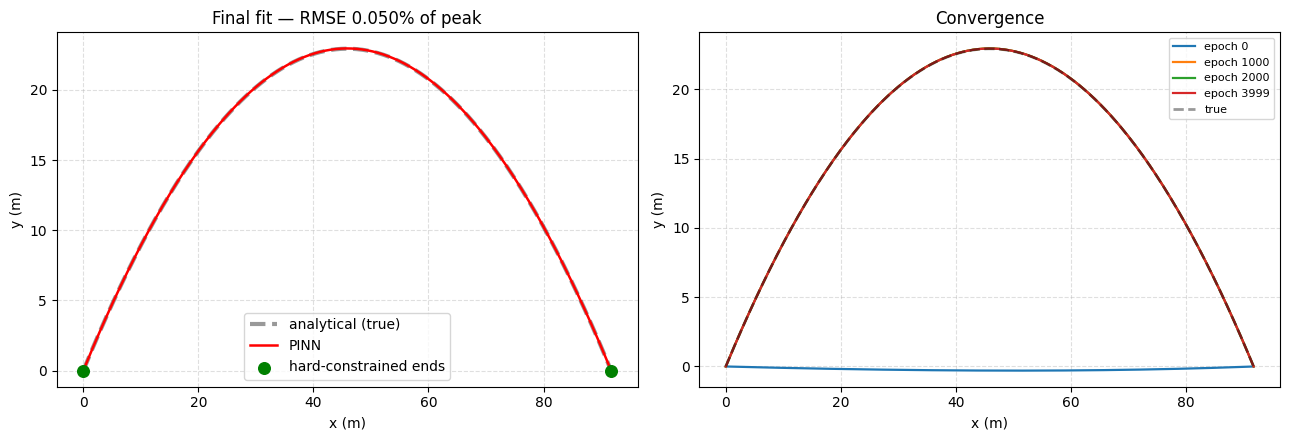

Final RMSE = 0.0503% of peak height


In [7]:
x_plot = xi_plot.cpu().numpy().squeeze()*x_max
y_true = analytic_y(x_plot)
with torch.no_grad():
    y_pred = (trajectory(xi_plot)*y_ref).cpu().numpy().squeeze()
rmse_pct = np.sqrt(np.mean((y_pred-y_true)**2))/y_true.max()*100

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].plot(x_plot, y_true, 'k--', lw=3, alpha=0.4, label='analytical (true)')
ax[0].plot(x_plot, y_pred, 'r-', lw=1.8, label='PINN')
ax[0].scatter([0, x_max], [0, 0], color='green', s=70, zorder=5, label='hard-constrained ends')
ax[0].set_xlabel('x (m)'); ax[0].set_ylabel('y (m)')
ax[0].set_title(f'Final fit — RMSE {rmse_pct:.3f}% of peak'); ax[0].legend(); ax[0].grid(True, ls='--', alpha=0.4)
for s in snaps:
    ax[1].plot(x_plot, s['y'], lw=1.6, label=f"epoch {s['epoch']}")
ax[1].plot(x_plot, y_true, 'k--', lw=2, alpha=0.4, label='true')
ax[1].set_xlabel('x (m)'); ax[1].set_ylabel('y (m)'); ax[1].set_title('Convergence'); ax[1].legend(fontsize=8); ax[1].grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"Final RMSE = {rmse_pct:.4f}% of peak height")

## What I take away from Notebook 1
- Normalising the inputs/outputs and **hard-constraining the endpoints** turned a wiggly, high-error
  fit into a smooth loss and an RMSE well under 0.1%. The architecture, not a penalty, now guarantees
  the launch and landing.
- The catch: this network only knows **one** trajectory. It has no idea what $u$ or $\theta$ are —
  change them and it can't adapt. That's the limitation **Notebook 2** removes by feeding $(u,\theta)$
  in as inputs, so a single network covers a whole family of launches. I'll also show there, with a
  sensitivity map, exactly how much that generalisation buys me over this single-shot model.